In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import plotly.graph_objects as go
import sys
sys.path.append("../")
from utils import metrics
from scipy import stats
from tqdm import tqdm
from background_removal.main_background_removal import main_background_removal

In [2]:
def compute_grad_magnitude(img):
    grad_x = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=1, dy=0)
    grad_y = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=0, dy=1)
    grad_module = cv2.magnitude(grad_x, grad_y)
    return np.uint8(grad_module)

In [3]:
def get_discriminative_mask(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h, s, v = cv2.split(hsv_image)
    edges_s = compute_grad_magnitude(s)

    mask_s = edges_s
    mask_s[mask_s < 75] = 0
    mask_s[mask_s != 0] = 255

    mask = mask_s
    

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(10, 5)))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(5, 10)))

    # plt.imshow(mask,cmap='gray')
    # plt.show()

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

    #For each label except background, get area and pick the two largest (possible two paintings)
    component_info = [(i, stats[i, 4]) for i in range(1, num_labels)]
    component_info.sort(key=lambda c: c[1], reverse=True)
    top_two_labels = [c[0] for c in component_info[:2]]

    new_mask = np.zeros_like(mask)

    for label in top_two_labels:
        
        # Create a mask of only this component
        ys, xs = np.where(labels == label)
        points = np.column_stack((xs, ys))
        
        # Get rotated rectangle from these points
        rect = cv2.minAreaRect(points)
        box = cv2.boxPoints(rect).astype(int)
        
        # Fill the rectangle in the mask
        cv2.fillPoly(new_mask, [box], 255)
        
    # plt.imshow(new_mask,cmap='gray')
    # plt.show()  
    
    return new_mask

def get_masks(img) -> list:
    
    AREA_THRESHOLD = (0.2*img.shape[0]) * (0.2*img.shape[1])
    discriminative_mask = get_discriminative_mask(img)

    # Check if there is more than one painting (big area)
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(discriminative_mask)
    small_areas = np.sum(stats[1:, 4] < AREA_THRESHOLD)
    # print(num_labels - small_areas - 1)
    if num_labels - small_areas - 1 > 1:
        
        #Sort stats from left painting to right painting (in case there are more than 2 in the future)
        stats_no_background = stats[1:]
        stats_no_background = stats_no_background[np.argsort(stats_no_background[:, 0])]
        
        #Compute their distances to get their image slice
        left_painting_x = stats_no_background[0, 0] + stats_no_background[0, 2]
        right_painting_x = stats_no_background[1, 0]
        distance = right_painting_x - left_painting_x
        middle_pos = left_painting_x + distance//2

        
        left_painting = img[:, 0:middle_pos]
        right_painting = img[:, middle_pos:]
        
        _, left_mask = main_background_removal(left_painting)
        _, right_mask = main_background_removal(right_painting)
        return [left_mask, right_mask]

    # print("Doing single mask")
    # plt.imshow(img)
    # plt.show()
    _, mask = main_background_removal(img)
    return [mask]

In [4]:
def has_impulse_noise(img, diff_threshold=60, ratio_threshold=0.01):
    median = cv2.medianBlur(img, 3)
    diff = cv2.absdiff(img, median)
    noisy_pixels = np.any(diff > diff_threshold, axis=2)
    noise_ratio = np.sum(noisy_pixels) / noisy_pixels.size
    return noise_ratio > ratio_threshold

50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190


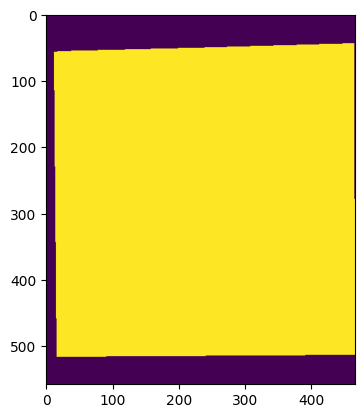

In [ ]:
img1 = cv2.imread("../data/qsd2_w3/00022.jpg", cv2.IMREAD_UNCHANGED)
if has_impulse_noise(img1):
    img1 = cv2.medianBlur(img1, 3)
masks = get_masks(img1)
_, mask = main_background_removal(img1)
plt.imshow(mask)
plt.show()
print("Hola")

50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190


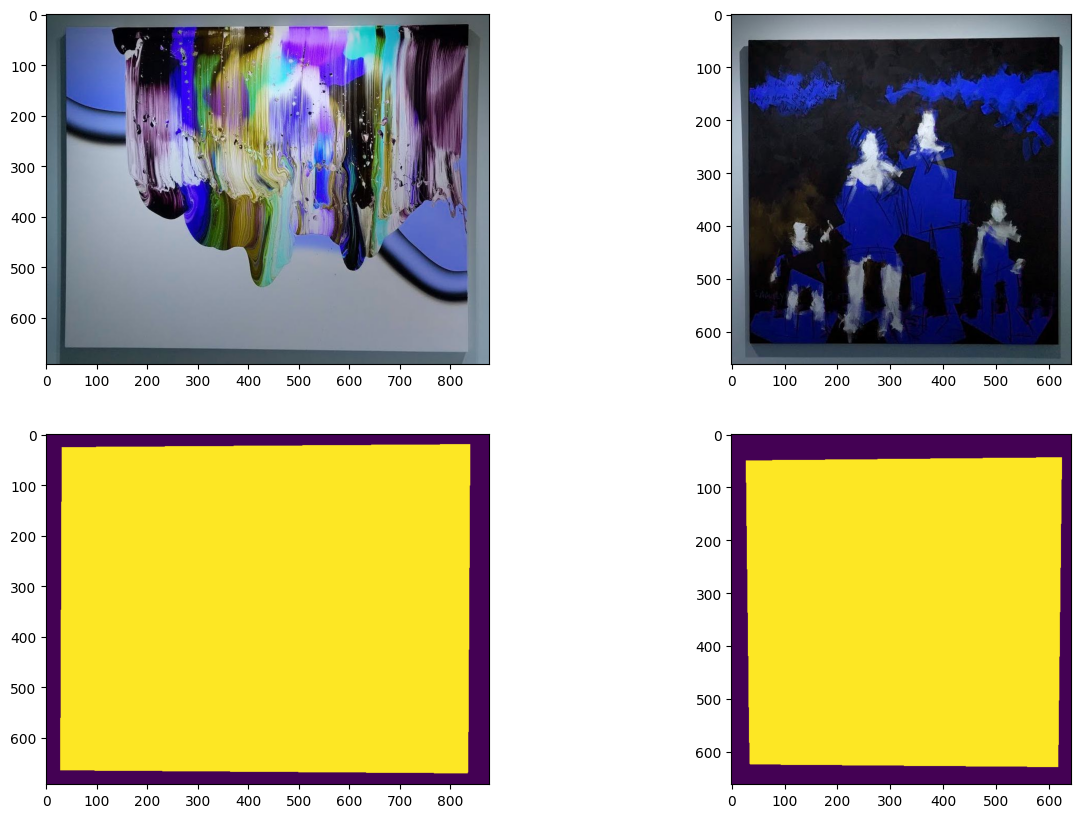

In [6]:
img1 = cv2.imread("../data/qsd2_w3/00021.jpg", cv2.IMREAD_UNCHANGED)
img2 = cv2.imread("../data/qsd2_w3/00009.jpg", cv2.IMREAD_UNCHANGED)
f, ax = plt.subplots(2, 2, figsize=(15,10))
ax[0][0].imshow(img1)
_, mask = main_background_removal(img1)
ax[1][0].imshow(mask)
ax[0][1].imshow(img2)
_, mask = main_background_removal(img2)
ax[1][1].imshow(mask)
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

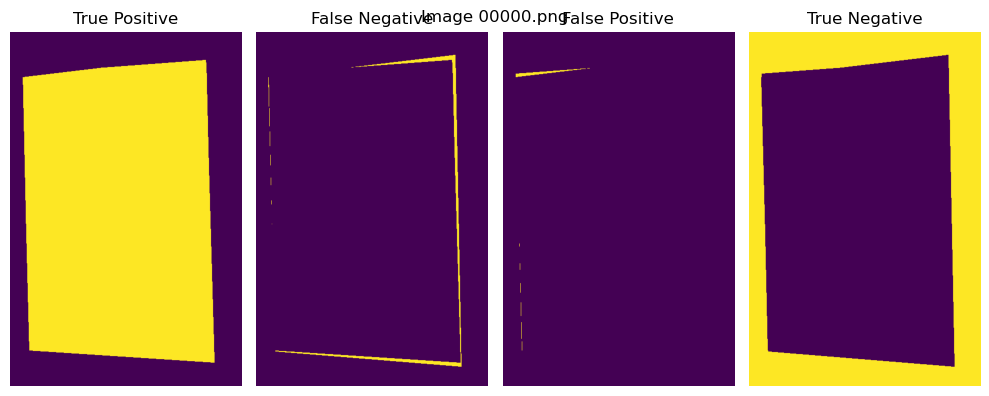

  3%|▎         | 1/30 [00:00<00:20,  1.45it/s]

Precision: 0.9968776009968584
Recall: 0.9737304623250655
F_score: 0.9851680863051442


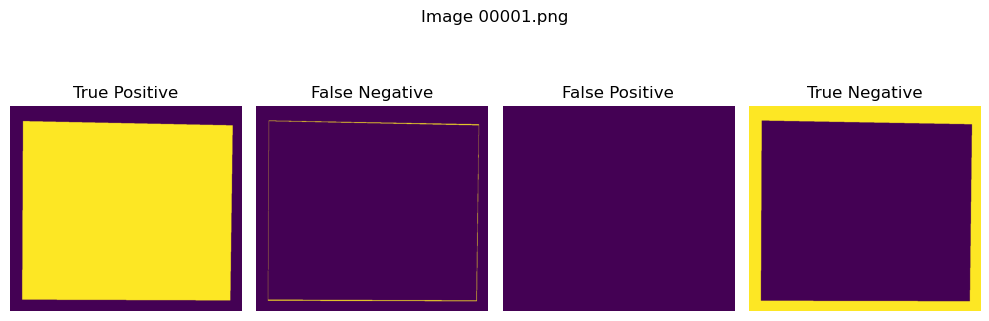

  7%|▋         | 2/30 [00:01<00:26,  1.08it/s]

Precision: 1.0
Recall: 0.9872732104823827
F_score: 0.9935958531265422


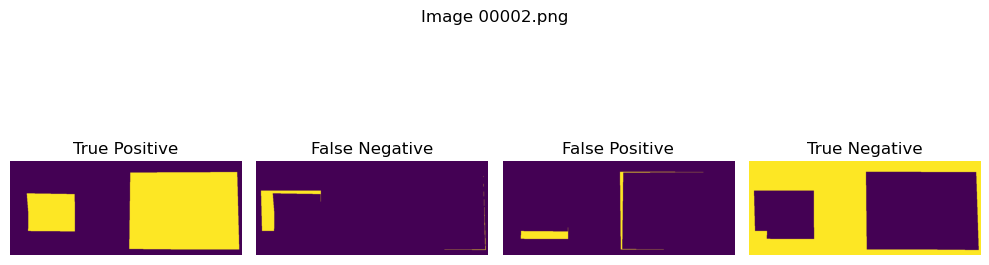

 10%|█         | 3/30 [00:02<00:23,  1.16it/s]

Precision: 0.9437978596351544
Recall: 0.9369358897613084
F_score: 0.94035435654393


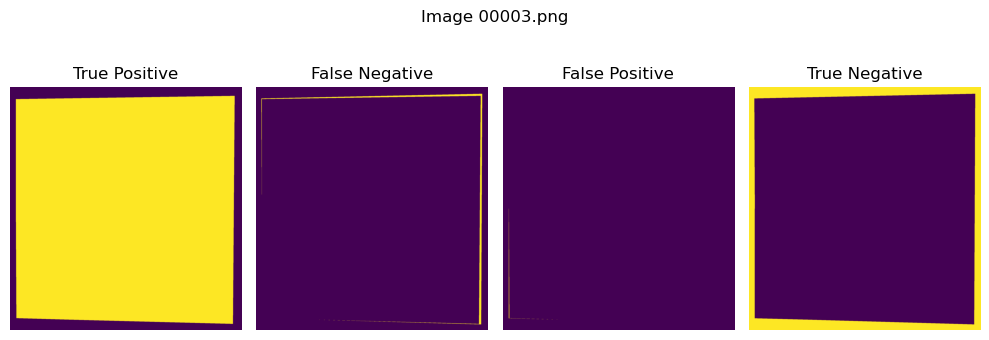

 13%|█▎        | 4/30 [00:07<00:59,  2.28s/it]

Precision: 0.9990374355751975
Recall: 0.983898091530427
F_score: 0.9914099705144173


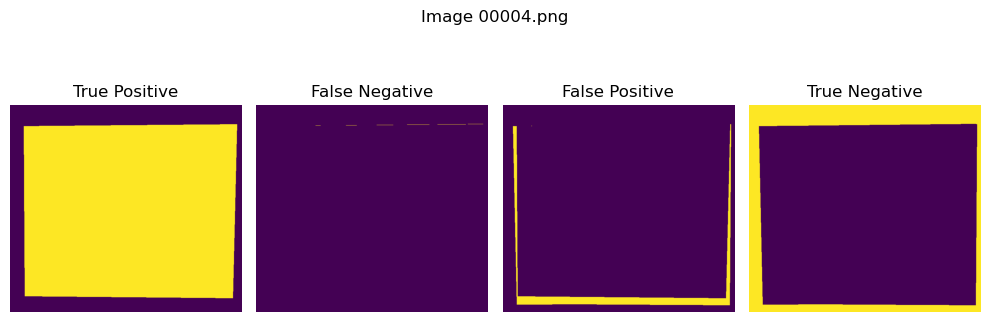

 17%|█▋        | 5/30 [00:07<00:43,  1.72s/it]

Precision: 0.9371311000071496
Recall: 0.9991276361480478
F_score: 0.967136843054548


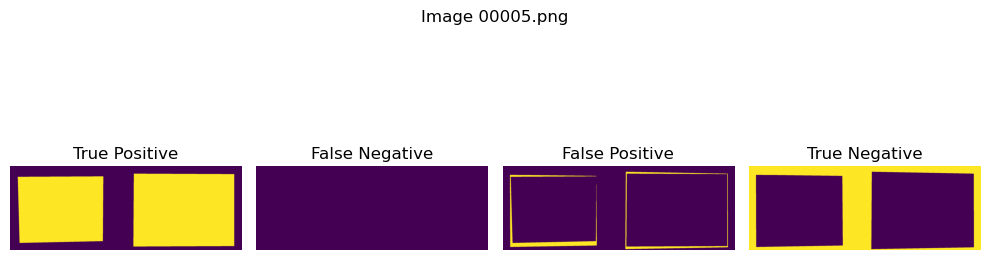

 20%|██        | 6/30 [00:10<00:47,  1.97s/it]

Precision: 0.9252503231004519
Recall: 1.0
F_score: 0.9611740478613866


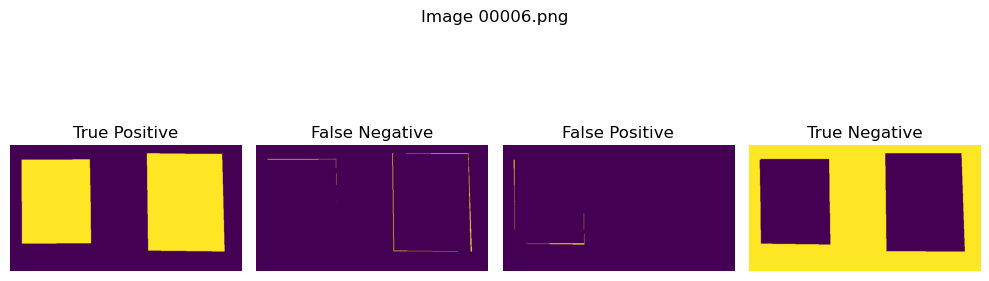

 23%|██▎       | 7/30 [00:10<00:36,  1.57s/it]

Precision: 0.9938191236175277
Recall: 0.9827846383874184
F_score: 0.9882710807311607


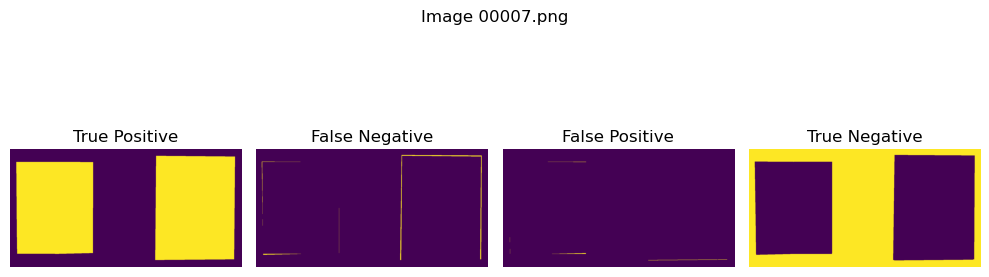

 27%|██▋       | 8/30 [00:12<00:35,  1.62s/it]

Precision: 0.9964188794442483
Recall: 0.980191125530087
F_score: 0.988238388436739


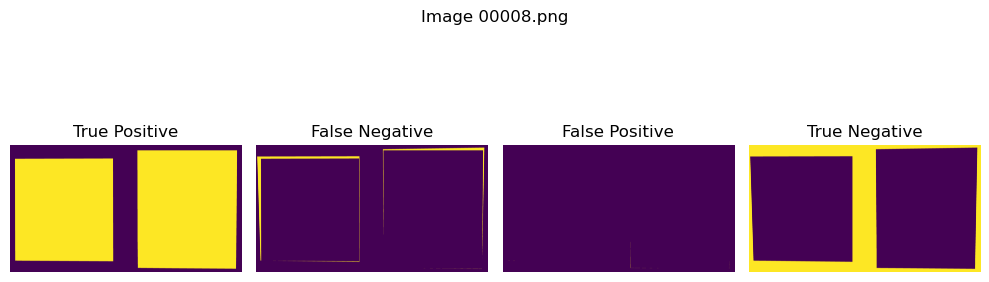

 30%|███       | 9/30 [00:24<01:40,  4.77s/it]

Precision: 0.9998108603452518
Recall: 0.9643236843966183
F_score: 0.9817466885137394


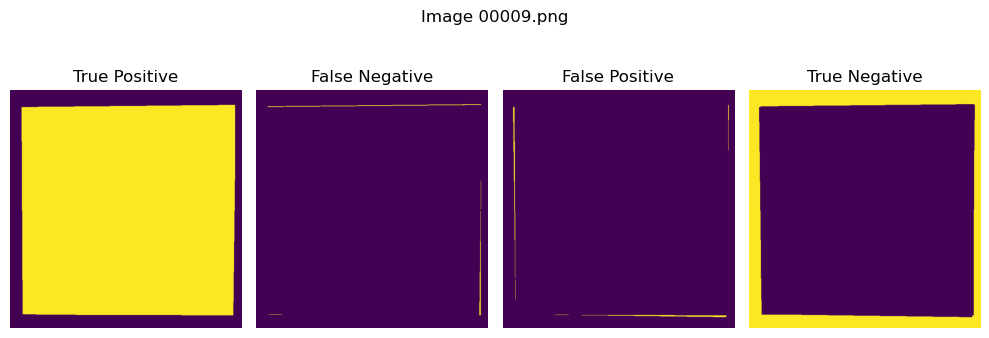

 33%|███▎      | 10/30 [00:25<01:10,  3.51s/it]

Precision: 0.9925770181686872
Recall: 0.9943143529768694
F_score: 0.9934449260113147


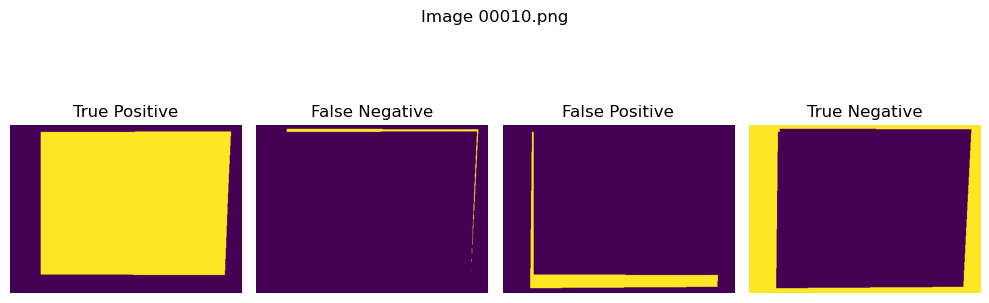

 37%|███▋      | 11/30 [00:25<00:49,  2.58s/it]

Precision: 0.9068450111139358
Recall: 0.9778521272782226
F_score: 0.9410109509540655


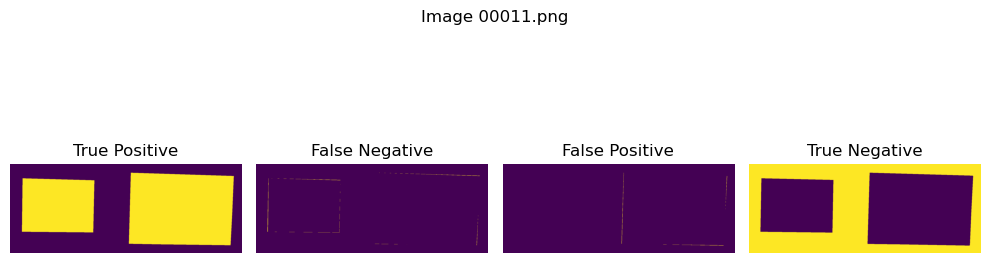

 40%|████      | 12/30 [00:27<00:40,  2.26s/it]

Precision: 0.9968233613371625
Recall: 0.9942249801825636
F_score: 0.9955224752750063


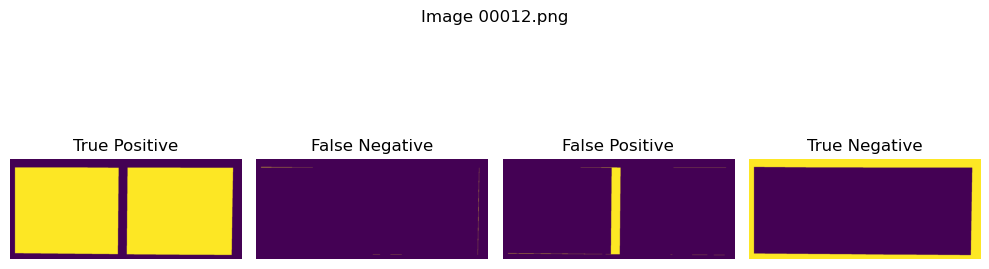

 43%|████▎     | 13/30 [00:28<00:33,  1.99s/it]

Precision: 0.9568628980363864
Recall: 0.9980894163973906
F_score: 0.9770414597044169


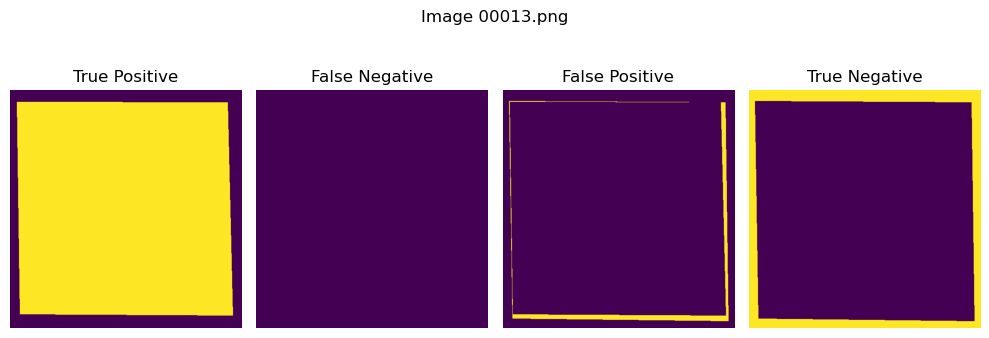

 47%|████▋     | 14/30 [00:28<00:24,  1.55s/it]

Precision: 0.956235559093645
Recall: 1.0
F_score: 0.9776282356677782


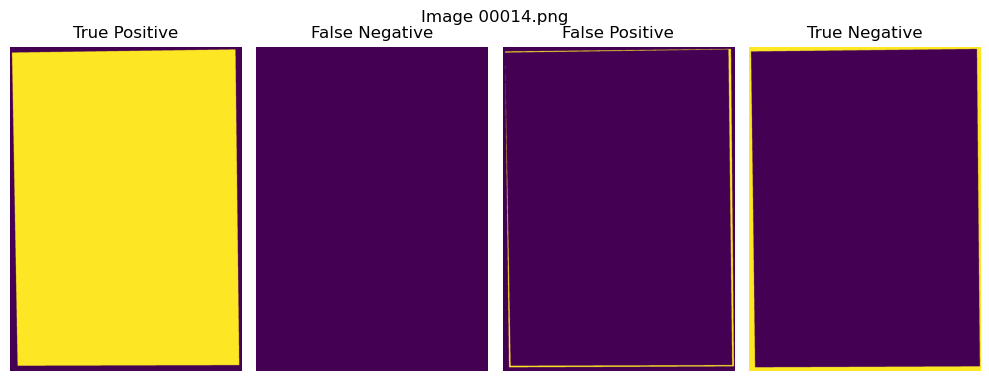

 50%|█████     | 15/30 [00:32<00:33,  2.22s/it]

Precision: 0.9806721551668713
Recall: 1.0
F_score: 0.9902417748526887


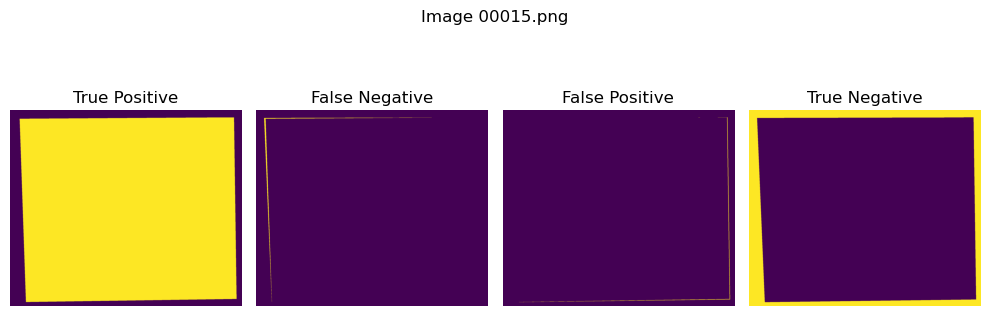

 53%|█████▎    | 16/30 [00:36<00:37,  2.70s/it]

Precision: 0.9958178933334685
Recall: 0.9943162717442149
F_score: 0.9950665160274383


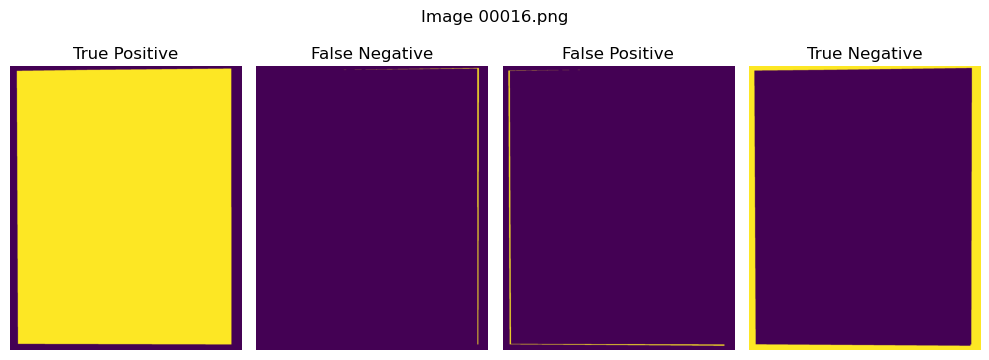

 57%|█████▋    | 17/30 [00:40<00:40,  3.13s/it]

Precision: 0.9904742858956433
Recall: 0.9936958599058676
F_score: 0.9920824575657939


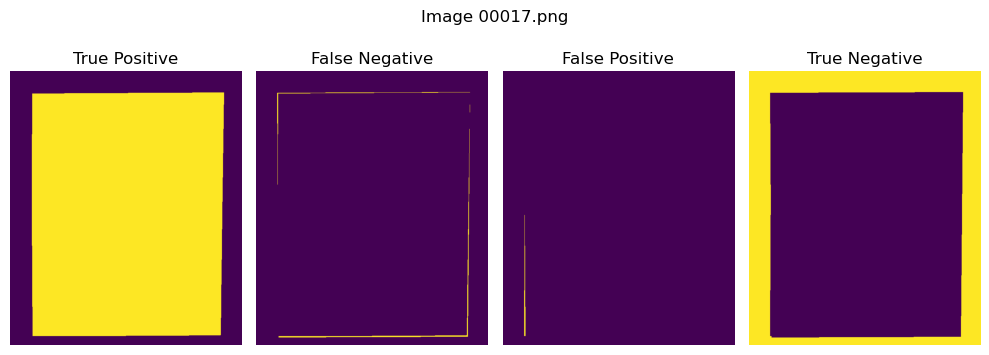

 60%|██████    | 18/30 [00:41<00:29,  2.46s/it]

Precision: 0.9977854847082472
Recall: 0.9878836259452248
F_score: 0.9928098667201508


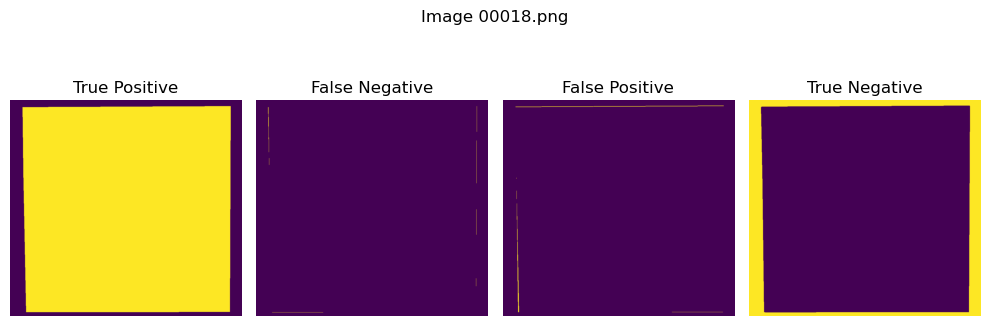

 63%|██████▎   | 19/30 [00:42<00:22,  2.05s/it]

Precision: 0.9955831698744361
Recall: 0.998659661326782
F_score: 0.9971190425697253


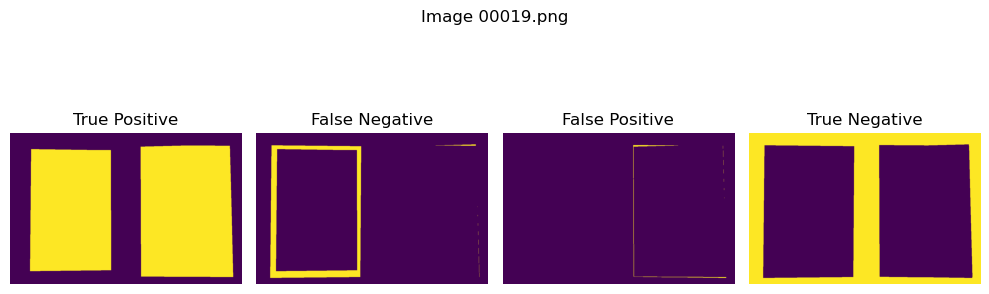

 67%|██████▋   | 20/30 [00:43<00:18,  1.81s/it]

Precision: 0.9930257797485005
Recall: 0.9099713995481001
F_score: 0.9496861775897016


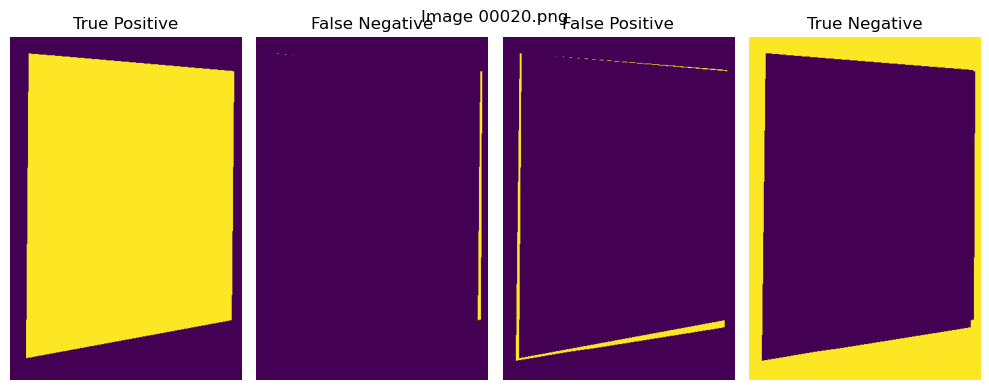

 70%|███████   | 21/30 [00:44<00:12,  1.39s/it]

Precision: 0.9692370335008845
Recall: 0.9890111464511877
F_score: 0.9790242518791661


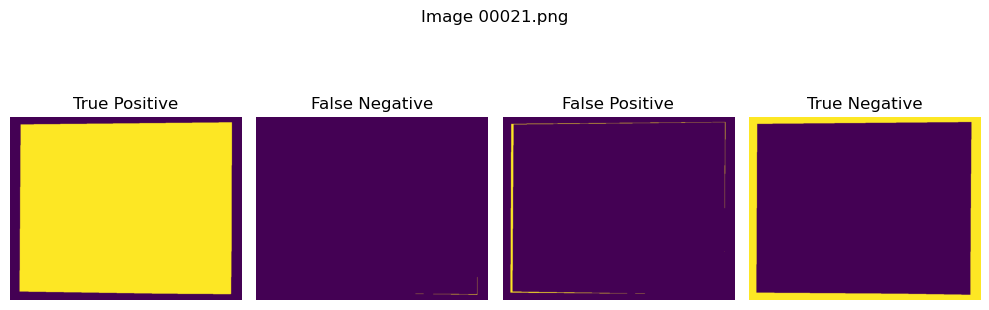

 73%|███████▎  | 22/30 [00:45<00:10,  1.26s/it]

Precision: 0.9844047180808638
Recall: 0.99935768173714
F_score: 0.9918248445909138


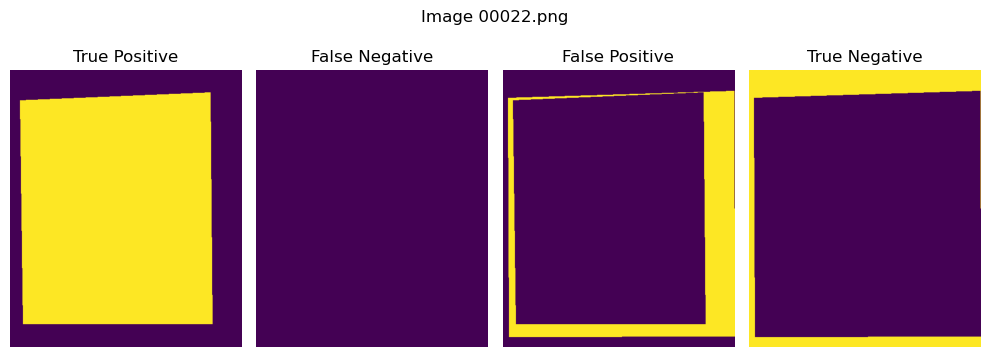

 77%|███████▋  | 23/30 [00:45<00:07,  1.02s/it]

Precision: 0.7898273330751285
Recall: 1.0
F_score: 0.8825737751117194


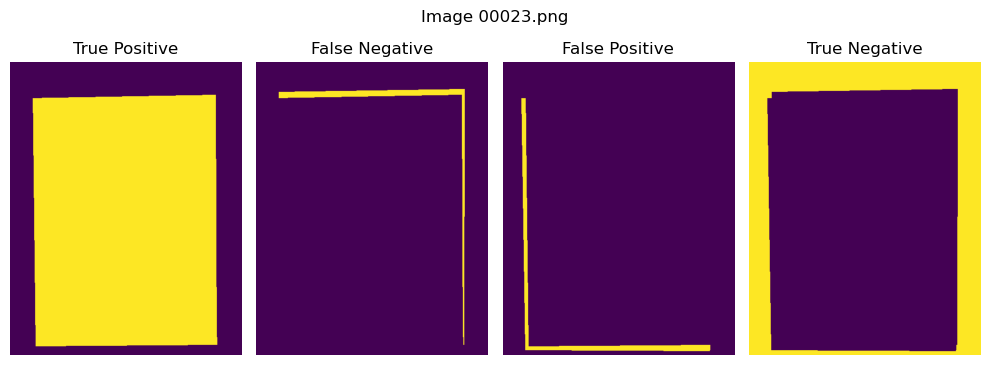

 80%|████████  | 24/30 [00:46<00:05,  1.13it/s]

Precision: 0.9596410127654128
Recall: 0.9649377264716947
F_score: 0.9622820809648047


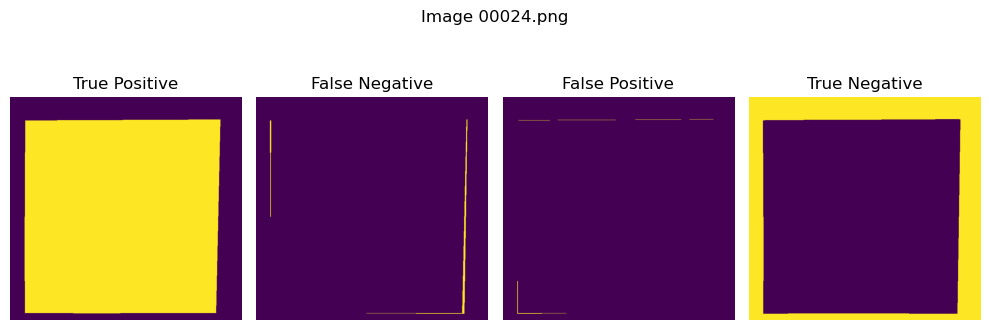

 83%|████████▎ | 25/30 [00:47<00:04,  1.12it/s]

Precision: 0.9973727278040797
Recall: 0.9879459827179435
F_score: 0.9926369750954371


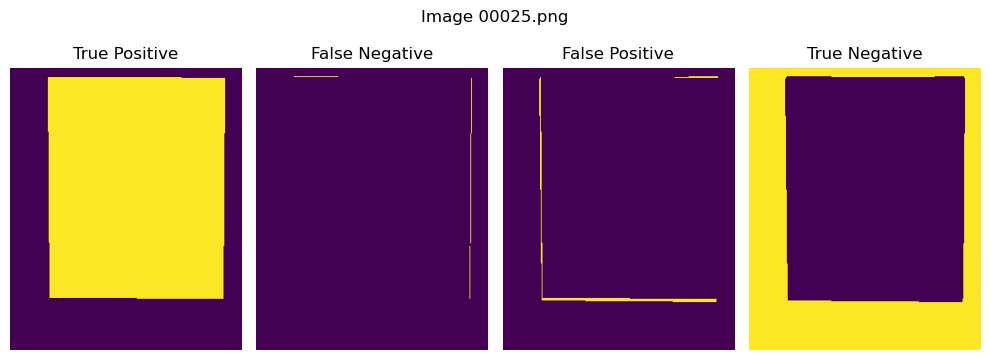

 87%|████████▋ | 26/30 [00:47<00:02,  1.41it/s]

Precision: 0.9783602126638098
Recall: 0.9943435438691606
F_score: 0.986287127825479


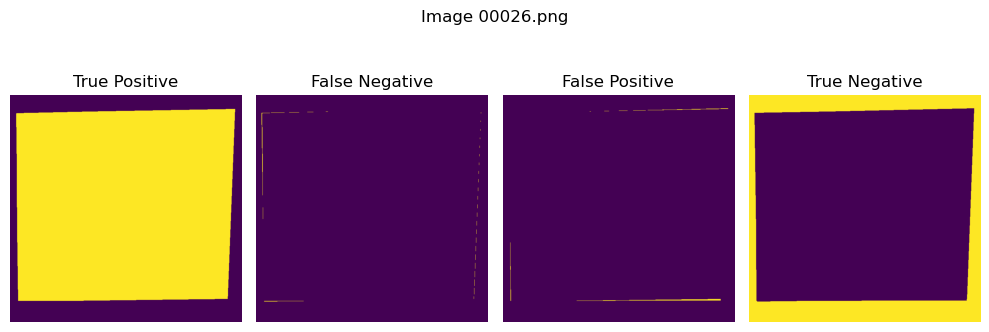

 90%|█████████ | 27/30 [00:48<00:02,  1.34it/s]

Precision: 0.9953500400858614
Recall: 0.9974007126660188
F_score: 0.9963743212369506


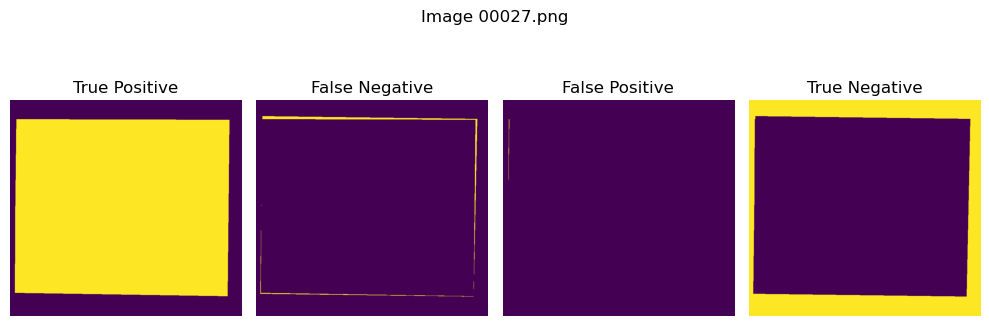

 93%|█████████▎| 28/30 [00:49<00:01,  1.22it/s]

Precision: 0.9993765431178805
Recall: 0.9804969464793126
F_score: 0.9898467291559033


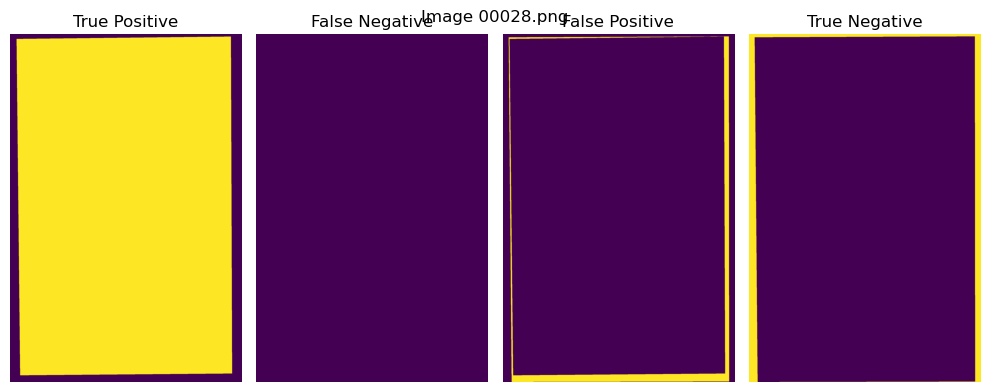

 97%|█████████▋| 29/30 [00:53<00:01,  1.91s/it]

Precision: 0.9508502831336991
Recall: 1.0
F_score: 0.9748060026485731


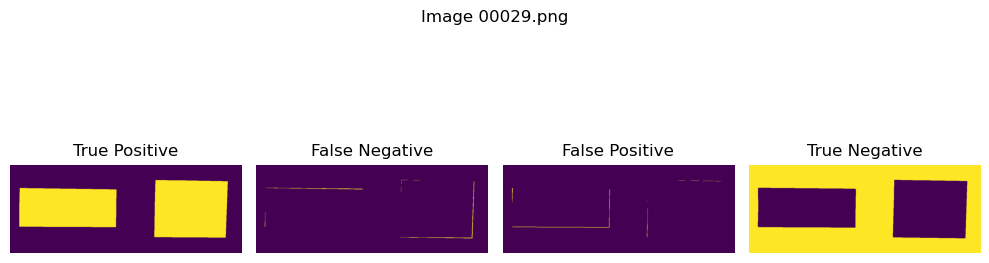

100%|██████████| 30/30 [00:54<00:00,  1.82s/it]

Precision: 0.9894244164899494
Recall: 0.9846065589444497
F_score: 0.987009608439818
Average F_score : 0.9780471638324816
Average Precision : 0.9722896706638797
Average Recall : 0.9851790911067834


In [5]:
score = 0
precision = 0
recall = 0

for i in tqdm(range(30)):
    img = cv2.imread(f"../data/qsd2_w3/{i:05d}.jpg", cv2.IMREAD_UNCHANGED)
    if has_impulse_noise(img):
        img = cv2.medianBlur(img, 3)
    correct_img = cv2.imread(f"../data/qsd2_w3/{i:05d}.png", cv2.IMREAD_UNCHANGED)
    
    masks = get_masks(img)
    result = masks[0]
    if len(masks) > 1:
        left_mask = masks[0]
        right_mask = masks[1]
        result = np.column_stack([left_mask, right_mask])
    
    TP = np.sum(correct_img & result)
    FN = np.sum(correct_img & (255 - result))
    FP = np.sum((255 - correct_img) & result)
    TN = np.sum((255 - correct_img) & (255 - result))
    
    f, ax = plt.subplots(1, 4, figsize=(10, 8))
    f.suptitle(f"Image {i:05d}.png")
    plt.axis('off')
    ax[0].imshow(correct_img & result)
    ax[0].axis('off')
    ax[0].set_title("True Positive")
    
    ax[1].imshow(correct_img & (255 - result))
    ax[1].axis('off')
    ax[1].set_title("False Negative")
    
    ax[2].imshow((255 - correct_img) & result)
    ax[2].axis('off')
    ax[2].set_title("False Positive")
    
    ax[3].imshow((255 - correct_img) & (255 - result))
    ax[3].axis('off')
    ax[3].set_title("True Negative")
    
    plt.tight_layout(rect=[0, 0, 1, 1.5])
    
    plt.show()
    
    
    P = TP / (TP + FP)
    R = TP / (TP + FN)
    F_score = 2*(P*R/(P + R))
    
    score = score + F_score
    precision += P
    recall += R
    
    print(f"Precision: {P}\nRecall: {R}\nF_score: {F_score}")
    
print(f"Average F_score : {score/30}")
print(f"Average Precision : {precision/30}")
print(f"Average Recall : {recall/30}")